# Day 6: Sequence Models in Deep Learning

In [ ]:
%load_ext autoreload
%autoreload 2

### Exercise 6.1 
Convince yourself that a RNN is just an FF unfolded in time. Complete the `backpropagation()` method in the `NumpyRNN` class in 

    lxmls/deep_learning/numpy_models/rnn.py 
    
and compare it with

    lxmls/deep_learning/numpy_models/mlp.py.

### WSJ Data
To work with RNNs we will use the Part-of-speech data-set seen in the sequence models day.

In [1]:
# Load Part-of-Speech data 
from lxmls.readers.pos_corpus import PostagCorpusData
data = PostagCorpusData()

Load and configure the NumpyRNN. Remember to use reload if you want to modify the code inside the rnns module

In [60]:
import numpy as np
from lxmls.deep_learning.rnn import RNN
from lxmls.deep_learning.utils import index2onehot, logsumexp


class NumpyRNN(RNN):

    def __init__(self, **config):
        # This will initialize
        # self.config
        # self.parameters
        RNN.__init__(self, **config)

    def predict(self, input=None):
        """
        Predict model outputs given input
        """
        p_y = np.exp(self.log_forward(input)[0])
        return np.argmax(p_y, axis=1)

    def update(self, input=None, output=None):
        """
        Update model parameters given batch of data
        """
        loss, gradients = self.backpropagation(input, output)
        learning_rate = self.config['learning_rate']
        # Update each parameter with SGD rule
        num_parameters = len(self.parameters)
        for m in range(num_parameters):
            # Update weight
            self.parameters[m] -= learning_rate * gradients[m]
        return loss
        
    def log_forward(self, input):
        W_e, W_x, W_h, W_y = self.parameters
        z_e = W_e[input]
        z_x = z_e @ W_x.T
        h = np.zeros((len(input)+1, W_h.shape[0]))
        for m in range(len(input)):
            z_h = z_x[m] + h[m] @ W_h.T
            h[m+1] = 1/(1+np.exp(-z_h))
        z_y = h[1:] @ W_y.T
        log_p_y = z_y - np.log(np.sum(np.exp(z_y), axis=1,keepdims=True))
        y = np.exp(log_p_y)
        return log_p_y, y, h, z_e, input

        
        
    def backpropagation(self, input, output):

        '''
        Compute gradientes, with the back-propagation method
        inputs:
            x: vector with the (embedding) indicies of the words of a
                sentence
            outputs: vector with the indicies of the tags for each word of
                        the sentence outputs:
            gradient_parameters: vector with parameters gradientes
        '''

        # Get parameters and sizes
        W_e, W_x, W_h, W_y = self.parameters
        nr_steps = input.shape[0]

        log_p_y, y, h, z_e, input = self.log_forward(input)
        loss = - np.sum(log_p_y[np.arange(nr_steps),output]) / nr_steps

        # classif layer
        I = index2onehot(output, W_y.shape[0])
        
        # -1/nr_steps is a factor everywhere so we add it here
        grad_wrt_z_y = -(I-y)/nr_steps
        
        grad_y = grad_wrt_z_y.T @h[1:]
        grad_wrt_h = grad_wrt_z_y@W_y
        grad_wrt_z_h = grad_wrt_h * (h[1:] * (1-h[1:]))
        grad_x = grad_wrt_z_h.T @ z_e
        grad_e = np.zeros_like(W_e)
        grad_e[input] = grad_wrt_z_h @ W_x
        grad_h = np.zeros_like(W_h)#grad_wrt_z_h.T @ h[:-1]#
       # error_r = np.zeros(W_h.shape[1])
        for m in range(nr_steps-1,-1,-1):
            grad_h += grad_wrt_z_h[m] @ h[m]
            
        gradient_parameters = [
                    grad_e, grad_x, grad_h, grad_y
                ]

        return loss, gradient_parameters
        
    def cross_entropy_loss(self, input, output):
        """Cross entropy loss"""
        nr_steps = input.shape[0]
        log_probability = self.log_forward(input)[0]
        return -log_probability[range(nr_steps), output].mean()

model = NumpyRNN(
    input_size=data.input_size,
    embedding_size=50,
    hidden_size=20,
    output_size=data.output_size,
    learning_rate=0.1
)

#### Milestone 1:

As in the case of the feed-forward networks you can use the following setup to test step by step the implementation of the gradients. First compute the cost variation for the variation of a single weight

In [9]:
W_e, W_x, W_h, W_y = model.parameters

W_e.shape

W_x.shape

W_h.shape

W_y.shape

(12, 20)

In [61]:
from lxmls.deep_learning.rnn import get_rnn_parameter_handlers, get_rnn_loss_range

# Get functions to get and set values of a particular weight of the model
get_parameter, set_parameter = get_rnn_parameter_handlers(
    layer_index=-1,
    row=0, 
    column=0
)

# Get batch of data
batch = data.batches('train', batch_size=1)[0]

# Get loss and weight value
current_loss = model.cross_entropy_loss(batch['input'], batch['output'])
current_weight = get_parameter(model.parameters)

# Get range of values of the weight and loss around current parameters values
weight_range, loss_range = get_rnn_loss_range(model, get_parameter, set_parameter, batch)

In [6]:
batch['input']

log_p_y, y, h, z_e, input = model.log_forward(batch['input'])

input

z_e

z_e.shape

h

h.shape

np.sum(y,1)

log_p_y

current_loss

%debug

> /tmp/ipykernel_9134/116120638.py(14)<module>()
     12 
     13 # Get loss and weight value
---> 14 current_loss = model.cross_entropy_loss(batch['input'], batch['output'])
     15 current_weight = get_parameter(model.parameters)
     16 



ipdb>  q


Then conmpute the desired gradient from your implementation

In [62]:
# Get the gradient value for that weight
loss,gradients = model.backpropagation(batch['input'], batch['output'])
current_gradient = get_parameter(gradients)

In [49]:
%debug

> /tmp/ipykernel_9134/3604129398.py(80)backpropagation()
     78         grad_e = np.zeros_like(W_e)
     79         grad_e[input] = grad_wrt_z_h @ W_x
---> 80         grad_h = grad_wrt_z_h.T @ h#np.zeros_like(W_h)
     81        # error_r = np.zeros(W_h.shape[1])
     82        # for m in range(nr_steps-1,-1,-1):



ipdb>  grad_wrt_z_h.shape


(5, 20)


ipdb>  h.shape


*** No help for '.shape'


ipdb>  !h.shape


(6, 20)


ipdb>  q


In [39]:
W_e.shape

(4786, 50)

In [37]:
grad_e, grad_x, grad_h, grad_y = gradients

In [17]:
W_x.shape


(20, 50)

In [17]:
%debug

> /tmp/ipykernel_9998/1103497524.py(80)backpropagation()
     78             error_r = error_h @ W_h
     79             grad_e += error_h @ W_x
---> 80             grad_x += error_h.T @ z_e[m]
     81             grad_h += error_h.T @ h[m]
     82         gradient_parameters = [



ipdb>  error_h.shape


(20,)


ipdb>  z_e.shape


(5, 50)


ipdb>  q


And finally call matlplotlib to plot the loss variation versus the gradient

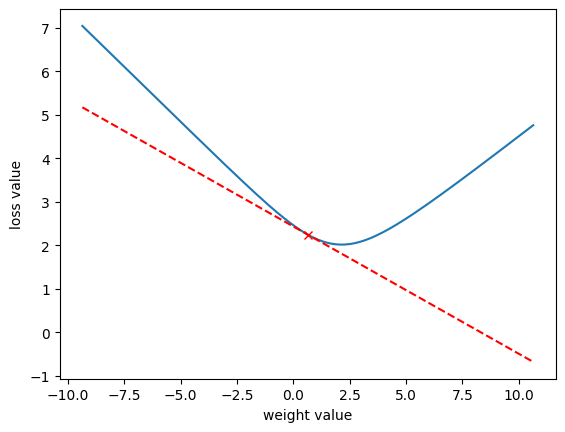

In [63]:
%matplotlib inline
import matplotlib.pyplot as plt
# Plot empirical
plt.plot(weight_range, loss_range)
plt.plot(current_weight, current_loss, 'xr')
plt.ylabel('loss value')
plt.xlabel('weight value')
# Plot real
h = plt.plot(
    weight_range,
    current_gradient*(weight_range - current_weight) + current_loss, 
    'r--'
)
plt.show()

#### Milestone 2:
After you have completed the gradients you can run the model in the POS task

In [64]:
# Hyper-parameters
num_epochs = 10

import numpy as np

# Get batch iterators for train and test
train_batches = data.batches('train', batch_size=1)
dev_set = data.batches('dev', batch_size=1)
test_set = data.batches('test', batch_size=1)

# Epoch loop
import time
start = time.time()
for epoch in range(num_epochs):

    # Batch loop
    for batch in train_batches:
        loss = model.update(input=batch['input'], output=batch['output'])
       # print(loss)

    # Evaluation dev
    is_hit = []
    for batch in dev_set:
        is_hit.extend(model.predict(input=batch['input']) == batch['output'])
    accuracy = 100*np.mean(is_hit)
    print("Epoch %d: dev accuracy %2.2f %%" % (epoch+1, accuracy))

print("Training took %2.2f seconds per epoch" % ((time.time() - start)/num_epochs))    
    
# Evaluation test
is_hit = []
for batch in test_set:
    is_hit.extend(model.predict(input=batch['input']) == batch['output'])
accuracy = 100*np.mean(is_hit)

# Inform user
print("Test accuracy %2.2f %%" % accuracy)

Epoch 1: dev accuracy 31.32 %
Epoch 2: dev accuracy 31.81 %
Epoch 3: dev accuracy 32.58 %
Epoch 4: dev accuracy 54.83 %
Epoch 5: dev accuracy 66.16 %
Epoch 6: dev accuracy 73.16 %
Epoch 7: dev accuracy 77.78 %
Epoch 8: dev accuracy 80.01 %
Epoch 9: dev accuracy 83.01 %
Epoch 10: dev accuracy 84.41 %
Training took 0.35 seconds per epoch
Test accuracy 84.75 %
